# GrantPilot Phase 1: Exploratory Data Analysis

CORDIS Horizon 2020 projects, cleaned pipeline output.

Goal of this notebook: understand the data we will model on, surface the
class-imbalance and skew we must design around, and document every decision
that shapes Phase 2. This is the data-readiness record for the project.

In [2]:
%pip install pyarrow

   ---------------------------------------- 0.0/27.9 MB ? eta -:--:--
   - -------------------------------------- 0.8/27.9 MB 8.5 MB/s eta 0:00:04
   - -------------------------------------- 1.3/27.9 MB 2.7 MB/s eta 0:00:10
   --- ------------------------------------ 2.4/27.9 MB 3.7 MB/s eta 0:00:07
   ---- ----------------------------------- 3.4/27.9 MB 3.7 MB/s eta 0:00:07
   ------ --------------------------------- 4.2/27.9 MB 3.8 MB/s eta 0:00:07
   ------- -------------------------------- 5.0/27.9 MB 3.8 MB/s eta 0:00:06
   -------- ------------------------------- 5.8/27.9 MB 3.8 MB/s eta 0:00:06
   --------- ------------------------------ 6.3/27.9 MB 3.8 MB/s eta 0:00:06
   ---------- ----------------------------- 7.1/27.9 MB 3.5 MB/s eta 0:00:06
   ----------- ---------------------------- 7.9/27.9 MB 3.6 MB/s eta 0:00:06
   ------------ --------------------------- 8.7/27.9 MB 3.6 MB/s eta 0:00:06
   ------------- -------------------------- 9.4/27.9 MB 3.6 MB/s eta 0:00:06
   ---

In [1]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (9, 5)

df = pd.read_parquet(Path("../data/clean/projects_clean.parquet"))
print(f"Loaded {len(df):,} projects, {df.shape[1]} columns")
df.head(3)

Loaded 35,104 projects, 37 columns


,id,acronym,status,title,startDate,endDate,totalCost,ecMaxContribution,topics,ecSignatureDate,...,hasCoordinator,numSME,numHES,numREC,numPRC,numPUB,topicCode,topicTitle,legalBasisCode,legalBasisTitle
0,632927,ERC-EuropePMC-1-2014,CLOSED,Support towards the Europe PMC initiative-Cont...,2014-01-01,2016-03-31,2.300000e+05,230000.0,ERC,2014-07-17,...,True,0,0,0,1,0,ERC,European Research Council,H2020-EU.1.1.,EXCELLENT SCIENCE - European Research Council ...
1,633002,ERCSC-VPRES-SUP2014,CLOSED,Support to the Vice-Presidents of the ERC Scie...,2014-01-01,2014-12-31,2.585000e+05,258500.0,ERC,2014-07-10,...,True,0,0,1,0,0,ERC,European Research Council,H2020-EU.1.1.,EXCELLENT SCIENCE - European Research Council ...
2,633053,EUROfusion,SIGNED,Implementation of activities described in the ...,2014-01-01,2022-12-31,1.329689e+09,678800000.0,EURATOM,2014-09-30,...,True,6,131,56,13,1,EURATOM,EURATOM,H2020-Euratom,Euratom


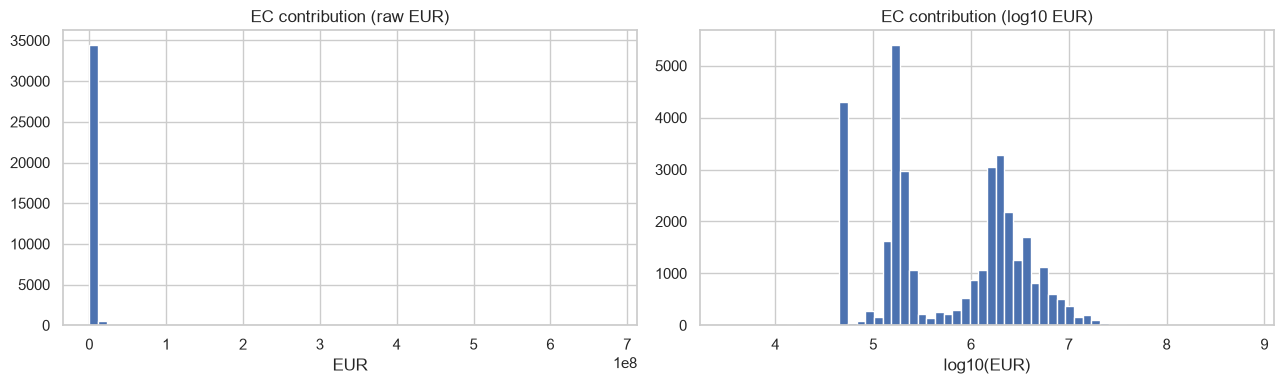

count         35,104
mean       1,933,931
std        5,560,805
min            3,150
25%          172,477
50%          905,966
75%        2,345,512
max      678,800,000
Name: ecMaxContribution, dtype: str


In [2]:
# EC contribution: the grant size. This is central to Model B (budget anomaly)
# and a key feature for Model A. Understand its distribution first.
money = df["ecMaxContribution"].dropna()

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].hist(money, bins=60)
axes[0].set_title("EC contribution (raw EUR)")
axes[0].set_xlabel("EUR")

axes[1].hist(np.log10(money[money > 0]), bins=60)
axes[1].set_title("EC contribution (log10 EUR)")
axes[1].set_xlabel("log10(EUR)")
plt.tight_layout()
plt.show()

print(money.describe().apply(lambda x: f"{x:,.0f}"))

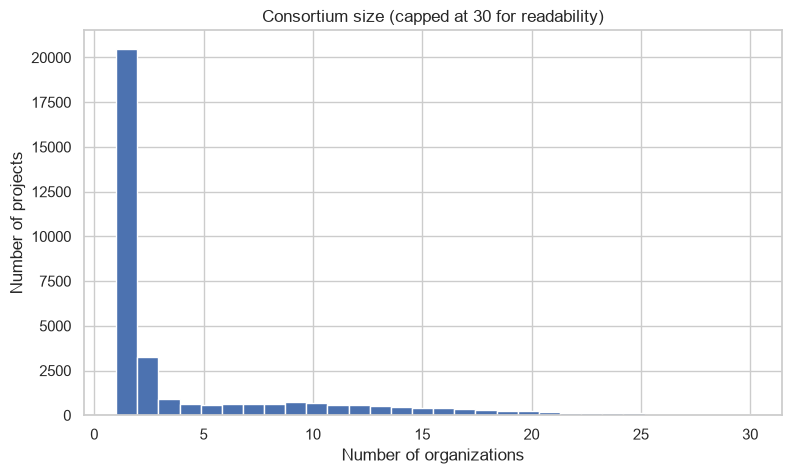

Solo-org projects: 58.4%
Median: 1, Mean: 5.1, Max: 208


In [3]:
# The single-org skew we discovered: 58% of projects are solo grants
# (ERC / MSCA), with a long tail of large consortia.
size = df["consortiumSize"].dropna()

fig, ax = plt.subplots()
ax.hist(size[size <= 30], bins=30)
ax.set_title("Consortium size (capped at 30 for readability)")
ax.set_xlabel("Number of organizations")
ax.set_ylabel("Number of projects")
plt.show()

print(f"Solo-org projects: {(size == 1).mean()*100:.1f}%")
print(f"Median: {size.median():.0f}, Mean: {size.mean():.1f}, Max: {size.max():.0f}")

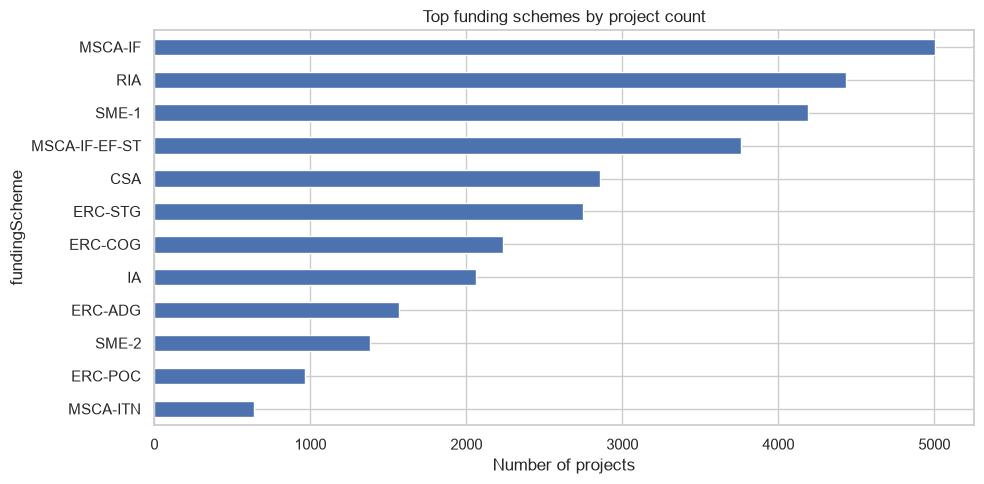

Median EC contribution by scheme (top schemes):
fundingScheme
IA               4,984,260 EUR
RIA              4,447,524 EUR
MSCA-ITN         3,845,729 EUR
ERC-ADG          2,490,000 EUR
ERC-COG          1,996,581 EUR
SME-2            1,699,253 EUR
ERC-STG          1,499,070 EUR
CSA                899,600 EUR
MSCA-IF            187,572 EUR
MSCA-IF-EF-ST      181,393 EUR
ERC-POC            150,000 EUR
SME-1               50,000 EUR
Name: ecMaxContribution, dtype: str


In [4]:
# Funding scheme: the strongest structural feature. ERC/MSCA vs RIA/IA
# separate the two regimes we just saw in money and consortium size.
scheme_counts = df["fundingScheme"].value_counts().head(12)
fig, ax = plt.subplots(figsize=(10, 5))
scheme_counts.sort_values().plot(kind="barh", ax=ax)
ax.set_title("Top funding schemes by project count")
ax.set_xlabel("Number of projects")
plt.tight_layout()
plt.show()

print("Median EC contribution by scheme (top schemes):")
print(
    df.groupby("fundingScheme")["ecMaxContribution"]
    .median()
    .loc[scheme_counts.index]
    .sort_values(ascending=False)
    .apply(lambda x: f"{x:,.0f} EUR")
)

status
CLOSED        30148
SIGNED         2837
TERMINATED     2119
Name: count, dtype: int64

TERMINATED projects: 2119 (6.04%)


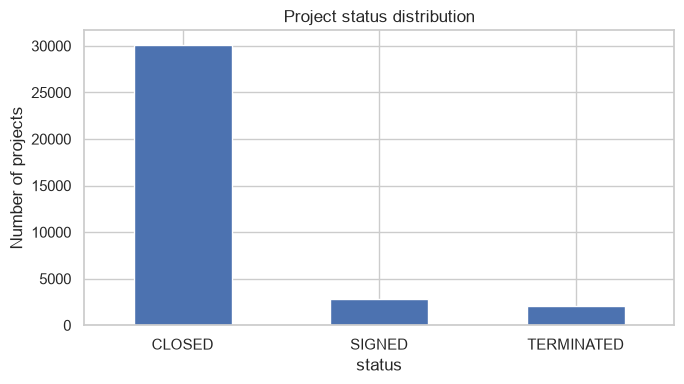

In [5]:
# Status: SIGNED / CLOSED / TERMINATED. TERMINATED = funded but failed,
# a rare but genuine negative signal we may use in the label strategy.
status_counts = df["status"].value_counts()
print(status_counts)
print()
print(f"TERMINATED projects: {(df['status'] == 'TERMINATED').sum()} "
      f"({(df['status'] == 'TERMINATED').mean()*100:.2f}%)")

fig, ax = plt.subplots(figsize=(7, 4))
status_counts.plot(kind="bar", ax=ax)
ax.set_title("Project status distribution")
ax.set_ylabel("Number of projects")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

count    35,104
mean      1,831
std         289
min           2
25%       1,803
50%       1,959
75%       1,990
max       3,988
Name: objectiveLen, dtype: str

Objectives under 100 chars: 18 (0.1%)


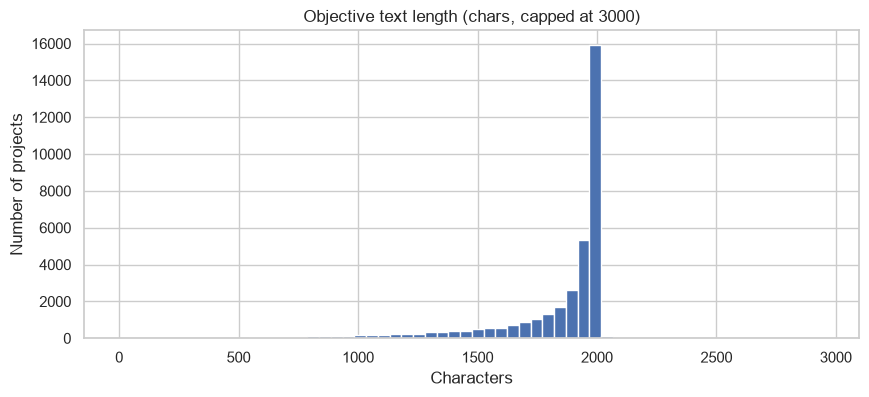

In [6]:
# Objective text feeds Model A (fundability scorer). Check its length
# distribution, very short objectives are low-signal and may need filtering.
obj_len = df["objectiveLen"]
print(obj_len.describe().apply(lambda x: f"{x:,.0f}"))
print(f"\nObjectives under 100 chars: {(obj_len < 100).sum()} "
      f"({(obj_len < 100).mean()*100:.1f}%)")

fig, ax = plt.subplots(figsize=(10, 4))
ax.hist(obj_len[obj_len < 3000], bins=60)
ax.set_title("Objective text length (chars, capped at 3000)")
ax.set_xlabel("Characters")
ax.set_ylabel("Number of projects")
plt.show()

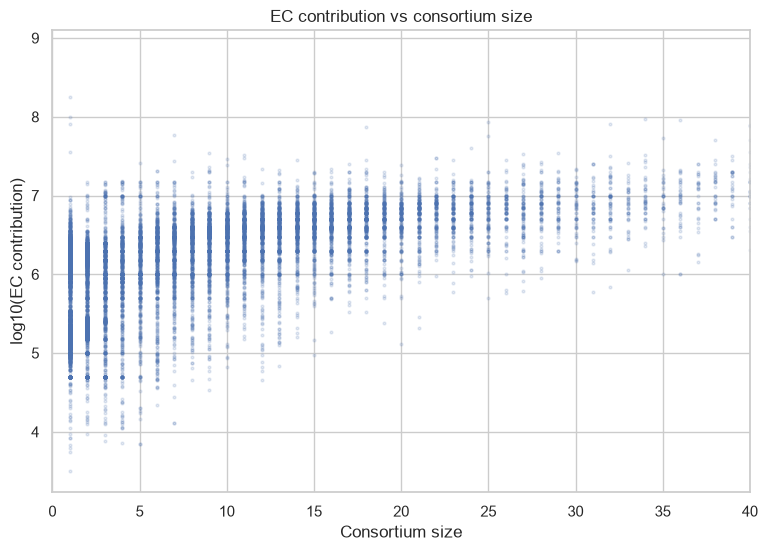

Correlation (size vs log money): 0.564


In [7]:
# Do money and consortium size move together? This confirms the two-regime
# structure and tells us whether size is redundant with money or adds signal.
sample = df[(df["ecMaxContribution"] > 0) & (df["consortiumSize"].notna())].copy()
sample["logMoney"] = np.log10(sample["ecMaxContribution"])

fig, ax = plt.subplots(figsize=(9, 6))
ax.scatter(sample["consortiumSize"], sample["logMoney"], s=4, alpha=0.15)
ax.set_title("EC contribution vs consortium size")
ax.set_xlabel("Consortium size")
ax.set_ylabel("log10(EC contribution)")
ax.set_xlim(0, 40)
plt.show()

corr = sample["consortiumSize"].corr(sample["logMoney"])
print(f"Correlation (size vs log money): {corr:.3f}")

## Phase 1 Findings (data-readiness summary)

1. **Two regimes.** EC contribution is bimodal: small single-beneficiary
   grants (ERC/MSCA, ~50k to 300k EUR) and large collaborative consortia
   (RIA/IA, ~1M to 10M EUR). Consortium size mirrors this (58% solo-org).
2. **Money is log-normal within regimes.** Models consume log10(money),
   never raw EUR (one 678M outlier otherwise dominates).
3. **Model B must condition on regime.** "Normal" budget differs by scheme
   and size, so the anomaly detector is conditioned, not global.
4. **Objective text is complete** (35,104/35,104) and usable for Model A.
5. **TERMINATED status** is a rare genuine negative signal, a candidate
   ingredient for the label strategy.

Next: define the Model A label (the negative-label proxy decision).

## The Model A Label Decision

**Task:** Predict whether a funded project will COMPLETE or be TERMINATED,
from its proposal text (objective) and structure (money, consortium, scheme).

- **Positive (success):** status == CLOSED  (30,148 projects)
- **Negative (failure):** status == TERMINATED  (2,119 projects, 6.6% of labeled)
- **Excluded:** status == SIGNED  (2,837, still running, outcome unknown)

**Why this label:** CORDIS contains no rejected proposals, so "will it be
funded" is unlabelable. Project outcome (closed vs terminated) is a REAL
recorded label requiring no synthetic proxy. The Reviewer agent therefore
reports post-funding RISK, a defensible, verifiable claim, not a funding
prediction.

**Known limitation (documented honestly):** this predicts post-award success,
not the award decision itself. Stated plainly in the project README.

**Imbalance:** ~93/7. Handled via class weighting and minority-class
precision/recall, never raw accuracy.